# EU G4 Debt-at-Risk — End-to-End Walkthrough

**Methodology:** Furceri, Giannone, Kisat, Lam & Li (May 2025), IMF WP/25/86  
**Countries:** France (FRA), Germany (DEU), Italy (ITA), Spain (ESP)  
**Horizon:** 3-year ahead (2027)  

This notebook runs the full pipeline:
1. Data pull (WEO, FSI, Eurostat sovereign yields, WUI)
2. Location-scale quantile regression (MSS 2019)
3. Skewed-t distribution fitting
4. Log-score density pooling
5. Debt-at-Risk extraction (P5/P50/P95)
6. Fiscal crisis early-warning logit
7. Charts and PowerPoint deck


In [24]:
import sys, os
# Ensure project root on path
ROOT = os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


Python: 3.12.1 (main, Nov 27 2025, 10:47:52) [GCC 13.3.0]
pandas: 2.2.2
numpy: 1.26.4


## Phase 1 — Data Pipeline

Pull macro-fiscal data from the following live sources:

| Dataset | Source |
|---|---|
| WEO (debt, balances, growth) | IMF DataMapper API + WEO Oct 2025 patch |
| Financial Stress (CLIFS) | ECB Data Portal — CLIFS dataset, series `CLIFS.M.{CC}._Z.4F.EC.CLIFS_CI.IDX` |
| 10Y sovereign yields & spreads | Eurostat `IRT_LT_MCBY_A` (SDMX-CSV) |
| World Uncertainty Index (WUI) | [worlduncertaintyindex.com](https://worlduncertaintyindex.com/wp-content/uploads/2026/01/WUI_Data.xlsx) — sheet T2 |

All data cached to `data/*.parquet` for reproducibility.


### Variable definitions

| Model variable | Panel column | Source | Series / code |
|---|---|---|---|
| `primary_balance` | `primary_balance_gdp` | IMF WEO | `GGXCNL_NGDP` — General govt net lending/borrowing (% GDP) |
| `rgdp_growth` | `rgdp_growth` | IMF WEO | `NGDP_RPCH` — Real GDP growth (%) |
| `cpi_inflation` | `cpi_inflation` | IMF WEO | `PCPIPCH` — CPI inflation (%) |
| `initial_debt` | `debt_gdp_lag` | IMF WEO | `GGXWDG_NGDP` — Gross govt debt (% GDP), lagged 1 year |
| `fsi` | `fsi` | ECB CLIFS — data-api.ecb.europa.eu | `CLIFS.M.{CC}._Z.4F.EC.CLIFS_CI.IDX` — monthly financial stress, annual mean; EU-27 + UK only; NaN for non-EU countries |
| `spread_10y` | `spread_10y` | Eurostat `IRT_LT_MCBY_A` | Annual 10Y Maastricht benchmark bond yield minus Bund (percentage points) |
| `wui` | `wui` | Ahir-Bloom-Furceri — worlduncertaintyindex.com | `WUI_Data.xlsx` sheet **T2**, quarterly iso3 panel → annual average |

> WEO 2025 rows for G4 are patched from the WEO Oct 2025 publication where the live API returns no data.  
> CLIFS is dimensionless ~[0, 1]; values ~0.4–0.6 during GFC / eurozone debt crisis. Non-EU countries receive NaN (zero pooling weight assigned downstream).


In [25]:
from data.imf_weo    import fetch_weo
from data.imf_fsi    import fetch_fsi
from data.ecb_spreads import fetch_spreads
from data.wui        import fetch_wui

print("=== WEO ===")
weo = fetch_weo(save=True)
print(f"WEO: {weo.shape[0]:,} rows, {weo['iso3'].nunique()} countries")
print(weo[weo["iso3"] == "FRA"].tail(5))


=== WEO ===
  Fetching WEO GGXWDG_NGDP …
  Fetching WEO GGXCNL_NGDP …
  Fetching WEO NGDP_RPCH …
  Fetching WEO PCPIPCH …
  Saved → /workspaces/debt_at_risk/data/weo_raw.parquet
WEO: 9,651 rows, 229 countries
     iso3  year  debt_gdp  primary_balance_gdp  rgdp_growth  cpi_inflation
3214  FRA  2021     112.8                 -6.6          6.8            2.1
3215  FRA  2022     111.4                 -4.7          2.8            5.9
3216  FRA  2023     109.6                 -5.4          1.6            5.7
3217  FRA  2024     113.2                 -5.8          1.1            2.3
3218  FRA  2025     116.0                 -5.1          0.9            0.9


In [26]:
print("=== Financial Stress Index — ECB CLIFS (CLIFS.M.{CC}._Z.4F.EC.CLIFS_CI.IDX) ===")
fsi = fetch_fsi(save=True)
print(f"CLIFS: {fsi.shape[0]:,} rows, {fsi['iso3'].nunique()} countries, "
      f"value range {fsi['fsi'].min():.3f}–{fsi['fsi'].max():.3f}")
print("\nG4 most recent years:")
print(fsi[fsi["iso3"].isin(["FRA","DEU","ITA","ESP"])].groupby("iso3").tail(3).to_string(index=False))


=== Financial Stress Index — ECB CLIFS (CLIFS.M.{CC}._Z.4F.EC.CLIFS_CI.IDX) ===
Fetching CLIFS from ECB Data Portal …
  AT (AUT): 56 annual obs
  BE (BEL): 36 annual obs
  BG (BGR): 25 annual obs
  CY (CYP): 28 annual obs
  CZ (CZE): 29 annual obs
  DE (DEU): 56 annual obs
  DK (DNK): 56 annual obs
  EE (EST): 12 annual obs
  ES (ESP): 56 annual obs
  FI (FIN): 56 annual obs
  FR (FRA): 56 annual obs
  GB (GBR): 56 annual obs
  GR (GRC): 33 annual obs
  HR (HRV): 27 annual obs
  HU (HUN): 27 annual obs
  IE (IRL): 43 annual obs
  IT (ITA): 56 annual obs
  LT (LTU): 23 annual obs
  LU (LUX): 32 annual obs
  LV (LVA): 21 annual obs
  MT (MLT): 27 annual obs
  NL (NLD): 56 annual obs
  PL (POL): 26 annual obs
  PT (PRT): 49 annual obs
  RO (ROU): 24 annual obs
  SE (SWE): 56 annual obs
  SI (SVN): 24 annual obs
  SK (SVK): 30 annual obs
CLIFS total: 1,109 rows, 28 countries, 1970–2026
  Saved → /workspaces/debt_at_risk/data/fsi_raw.parquet
CLIFS: 1,109 rows, 28 countries, value range 0.01

In [47]:
print("=== Eurostat Sovereign Yields & Spreads (IRT_LT_MCBY_A) ===")
spreads = fetch_spreads(save=True)
print(spreads)


=== Eurostat Sovereign Yields & Spreads (IRT_LT_MCBY_A) ===
  Fetching Eurostat 10Y sovereign yields (IRT_LT_MCBY_A) …
  Saved → /workspaces/debt_at_risk/data/ecb_spreads_raw.parquet
    iso3  year  yield_10y  spread_10y
0    DEU  1990    8.73000     0.00000
1    DEU  1991    8.45000     0.00000
2    DEU  1992    7.84000     0.00000
3    DEU  1993    6.51000     0.00000
4    DEU  1994    6.87000     0.00000
..   ...   ...        ...         ...
139  ITA  2021    0.81000     1.18000
140  ITA  2022    3.16000     2.02000
141  ITA  2023    4.28000     1.85000
142  ITA  2024    3.71000     1.39000
143  ITA  2025    3.59284     1.00078

[144 rows x 4 columns]


In [28]:
print("=== World Uncertainty Index (worlduncertaintyindex.com / WUI_Data.xlsx T2) ===")
wui = fetch_wui(save=True)
print(f"WUI: {wui.shape[0]:,} rows, {wui['iso3'].nunique()} countries")
print(wui.head(5))


=== World Uncertainty Index (worlduncertaintyindex.com / WUI_Data.xlsx T2) ===
  Parsed WUI sheet 'T2': 5088 rows
  Saved → /workspaces/debt_at_risk/data/wui_raw.parquet
WUI: 5,088 rows, 143 countries
  iso3  year       wui
0  AFG  1990  0.074118
1  AFG  1991  0.051335
2  AFG  1992  0.187919
3  AFG  1993  0.000000
4  AFG  1994  0.041010


In [48]:
from data.panel_builder import build_panel

print("=== Building Estimation Panel ===")
panel = build_panel(min_obs=20)
print(panel.describe())


=== Building Estimation Panel ===
Building panel …
Panel: 7675 rows × 13 cols, 220 countries
Saved → /workspaces/debt_at_risk/data/panel.parquet
              year     debt_gdp  primary_balance_gdp  rgdp_growth  \
count  7675.000000  6558.000000          6951.000000  7641.000000   
mean   2007.876352    55.630345            -2.540857     3.464821   
std      10.232441    38.908477            11.694923     5.679238   
min    1990.000000     0.000000          -557.500000   -54.400000   
25%    1999.000000    30.500000            -4.600000     1.500000   
50%    2008.000000    48.400000            -2.400000     3.600000   
75%    2017.000000    70.900000            -0.200000     5.800000   
max    2025.000000   300.000000           125.100000   148.000000   

       cpi_inflation         fsi  spread_10y          wui  debt_gdp_lag  \
count    7547.000000  856.000000  144.000000  4950.000000   6338.000000   
mean       10.708189    0.126663    0.944585     0.178083     55.376365   
std     

In [49]:
# Quick QA: coverage for G4
G4 = ["FRA", "DEU", "ITA", "ESP"]
for iso3 in G4:
    sub = panel[panel["iso3"] == iso3]
    nobs = sub[["debt_gdp", "primary_balance_gdp", "rgdp_growth"]].notna().all(axis=1).sum()
    print(f"{iso3}: {nobs} complete core observations  "
          f"(debt range: {sub['debt_gdp'].min():.0f}–{sub['debt_gdp'].max():.0f}% GDP)")


FRA: 36 complete core observations  (debt range: 37–116% GDP)
DEU: 35 complete core observations  (debt range: 39–81% GDP)
ITA: 36 complete core observations  (debt range: 102–154% GDP)
ESP: 36 complete core observations  (debt range: 36–119% GDP)


### Historical Debt/GDP trajectories for G4

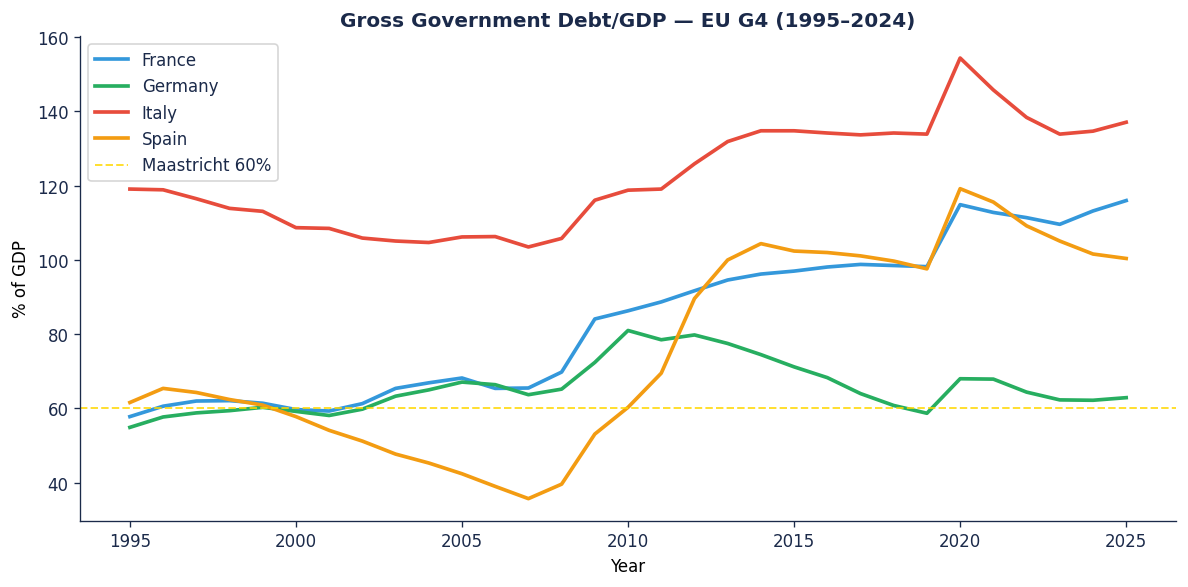

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"FRA": "#3498DB", "DEU": "#27AE60", "ITA": "#E74C3C", "ESP": "#F39C12"}
labels = {"FRA": "France", "DEU": "Germany", "ITA": "Italy", "ESP": "Spain"}

for iso3 in G4:
    hist = panel[(panel["iso3"] == iso3) & (panel["year"] >= 1995)].sort_values("year")
    ax.plot(hist["year"], hist["debt_gdp"], lw=2.2,
            color=colors[iso3], label=labels[iso3])

ax.axhline(60, color="gold", lw=1.2, ls="--", alpha=0.8, label="Maastricht 60%")
ax.set_title("Gross Government Debt/GDP — EU G4 (1995–2024)", fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("% of GDP")
ax.legend(); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Phase 2 — Location-Scale Quantile Regression (MSS 2019)

The Machado-Santos Silva three-step estimator:

$$d_{i,t+h} = \alpha_i + X'\beta + (\delta_i + X'\gamma)\,\varepsilon_{i,t+h}$$

Three steps:
1. FE-OLS on level → residuals $\hat{e}$
2. FE-OLS on $|\hat{e}|$ → scale $\hat{s}$
3. $z = \hat{e}/\hat{s}$; empirical quantiles; predicted $Q(\tau) = \hat{\mu} + q_z(\tau)\cdot\hat{s}$


In [51]:
from model.location_scale import run_all

print("Running MSS quantile regression (all conditioning variables × horizons) …")
print("This may take several minutes …")
qpreds = run_all(panel, horizons=[1, 3, 5])
print(f"\nQuantile predictions: {qpreds.shape[0]:,} rows")
print(qpreds.head(10))


Running MSS quantile regression (all conditioning variables × horizons) …
This may take several minutes …

  Horizon h=1:
    primary_balance … 6093 rows
    rgdp_growth … 6112 rows
    cpi_inflation … 6048 rows
    initial_debt … 6117 rows
    fsi … 803 rows
    spread_10y … 135 rows
    wui … 3964 rows

  Horizon h=3:
    primary_balance … 5654 rows
    rgdp_growth … 5673 rows
    cpi_inflation … 5611 rows
    initial_debt … 5678 rows
    fsi … 749 rows
    spread_10y … 127 rows
    wui … 3682 rows

  Horizon h=5:
    primary_balance … 5214 rows
    rgdp_growth … 5233 rows
    cpi_inflation … 5173 rows
    initial_debt … 5238 rows
    fsi … 695 rows
    spread_10y … 119 rows
    wui … 3400 rows

Saved quantile predictions → /workspaces/debt_at_risk/model/quantile_predictions.parquet

Quantile predictions: 81,518 rows
  iso3  year  horizon         cond_var        Q05        Q25        Q50  \
0  ABW  1996        1  primary_balance  33.787890  48.152848  54.396797   
1  ABW  1997       

In [52]:
# Check predictions for G4
print("Sample quantile predictions for France (h=3):")
print(qpreds[(qpreds["iso3"] == "FRA") & (qpreds["horizon"] == 3)].tail(10))


Sample quantile predictions for France (h=3):
      iso3  year  horizon cond_var        Q05        Q25        Q50  \
53875  FRA  2013        3      wui  38.381848  60.123912  72.795950   
53876  FRA  2014        3      wui  36.097262  58.861115  72.128687   
53877  FRA  2015        3      wui  38.031621  60.754431  73.998083   
53878  FRA  2016        3      wui  35.064736  58.511754  72.177499   
53879  FRA  2017        3      wui  36.211959  59.665337  73.334788   
53880  FRA  2018        3      wui  34.445736  58.375712  72.322942   
53881  FRA  2019        3      wui  41.063297  63.679587  76.861154   
53882  FRA  2020        3      wui  40.836405  63.434683  76.605752   
53883  FRA  2021        3      wui  38.853857  65.221053  80.588780   
53884  FRA  2022        3      wui  41.668792  67.076371  81.884799   

             Q75         Q95  
53875  85.019717  109.099943  
53876  84.926922  110.138822  
53877  86.773242  111.939686  
53878  85.359822  111.328356  
53879  86.520686 

## Phase 3a — Skewed-t Distribution Fitting

Fit Fernandez-Steel skewed-t parameters (ξ, ω, α, ν) to each set of five predicted quantiles
{Q5, Q25, Q50, Q75, Q95} using a fast **analytical closed-form approximation**:

- **ξ** pinned to Q50  
- **ν** estimated from upper-tail thickness ratio (Q95−Q75)/(Q75−Q50)  
- **α** estimated from asymmetry ratio log\[(Q95−Q50)/(Q50−Q05)\] / 2  
- **ω** estimated from IQR / (2 · t₀.₇₅(ν))

Runs in seconds across the full prediction set (vs. minutes for Nelder-Mead).


In [53]:
from model.quantile_fit import fit_distributions

print("Fitting skewed-t distributions …")
skt_params = fit_distributions(qpreds)
print(f"SKT params: {skt_params.shape[0]:,} rows")
print(skt_params[skt_params["iso3"] == "FRA"].head(8))


Fitting skewed-t distributions …
  Fitting skewed-t for 12918 rows (analytical approximation) …
  12918 / 12918 fitted successfully.
  Saved → /workspaces/debt_at_risk/model/skt_params.parquet
SKT params: 12,918 rows
    iso3  year  horizon         cond_var        Q05        Q25        Q50  \
214  FRA  1991        1  primary_balance  26.864328  37.064172  41.497691   
215  FRA  1992        1  primary_balance  27.275693  37.960335  42.604578   
216  FRA  1993        1  primary_balance  28.787954  40.646394  45.800846   
217  FRA  1994        1  primary_balance  31.234049  44.469948  50.223134   
218  FRA  1995        1  primary_balance  32.514895  46.481814  52.552750   
219  FRA  1996        1  primary_balance  34.841584  50.071692  56.691693   
220  FRA  1997        1  primary_balance  35.898864  51.750199  58.640224   
221  FRA  1998        1  primary_balance  36.404631  52.388464  59.336082   

           Q75        Q95         xi     omega     alpha   nu  
214  45.861011  57.357161

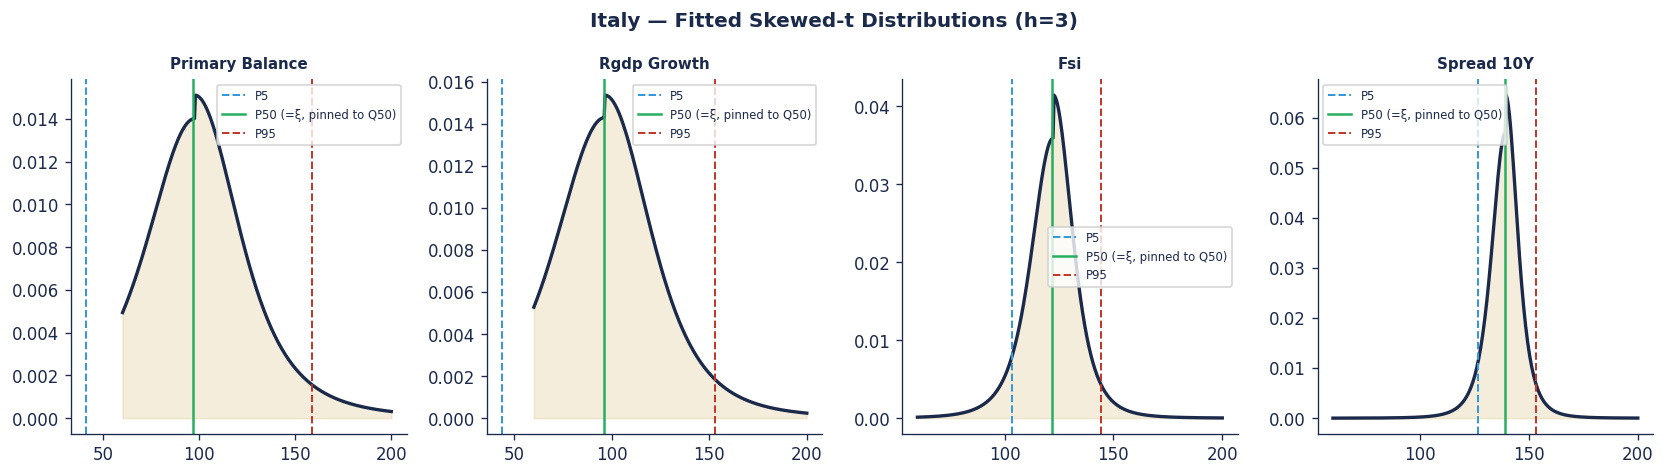

In [54]:
# Visualise fitted distributions for Italy h=3, one conditioning variable
# Note: ξ is analytically pinned to Q50 from the MSS quantile regression,
# so the median (P50) is by construction equal to the conditional median of
# debt/GDP. For mild right-skew the mode sits just left of ξ and the two
# nearly coincide — the median line will always be close to the PDF peak.
from model.quantile_fit import _fst_quantile
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("Italy — Fitted Skewed-t Distributions (h=3)", fontweight="bold")

cond_vars_show = ["primary_balance", "rgdp_growth", "fsi", "spread_10y"]
x_grid = np.linspace(60, 200, 300)

for ax, cv in zip(axes, cond_vars_show):
    sub = skt_params[
        (skt_params["iso3"] == "ITA") &
        (skt_params["horizon"] == 3) &
        (skt_params["cond_var"] == cv)
    ]
    if sub.empty: continue
    r = sub.sort_values("year").iloc[-1]
    if any(pd.isna([r["xi"], r["omega"], r["alpha"], r["nu"]])): continue

    from scipy.stats import t as t_dist
    gamma = np.exp(r["alpha"])
    omega, nu = r["omega"], r["nu"]
    xi    = r["xi"]

    def pdf(x):
        z = (x - xi) / omega
        c = 2.0 / (omega * (gamma + 1.0 / gamma))
        if z < 0:
            return c * t_dist.pdf(-z / gamma, df=nu) / gamma
        else:
            return c * t_dist.pdf(z * gamma, df=nu) * gamma

    y_pdf = np.array([pdf(xv) for xv in x_grid])
    ax.plot(x_grid, y_pdf, color="#1B2A4A", lw=2)
    ax.fill_between(x_grid, y_pdf, alpha=0.2, color="#C8A951")
    ax.axvline(_fst_quantile(0.05, xi, omega, r["alpha"], nu),
               color="#3498DB", lw=1.2, ls="--", label="P5")
    ax.axvline(_fst_quantile(0.50, xi, omega, r["alpha"], nu),
               color="#27AE60", lw=1.5, ls="-", label="P50 (=ξ, pinned to Q50)")
    ax.axvline(_fst_quantile(0.95, xi, omega, r["alpha"], nu),
               color="#C0392B", lw=1.2, ls="--", label="P95")
    ax.set_title(cv.replace("_", " ").title(), fontsize=9)
    ax.legend(fontsize=7)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()


## Phase 3b — Log-Score Density Pooling

Optimal mixture weights computed via rolling out-of-sample log-score maximisation
(Crump et al. 2022), country-specific, from 2005 onward.

$$w^* = \arg\max_{w\geq 0,\,\sum w=1} \sum_{t \in \text{val}} \log\left[\sum_k w_k f_k(d_{t+h}|X_t)\right]$$


In [55]:
from risk.pooling import compute_country_weights

print("Computing log-score pooling weights (h=3) …")
weights = compute_country_weights(skt_params, panel, horizon=3)

# Show G4 weights
print("\nPooling weights for G4:")
print(weights[weights["iso3"].isin(["FRA","DEU","ITA","ESP"])]
      .pivot(index="iso3", columns="cond_var", values="weight")
      .round(3))


Computing log-score pooling weights (h=3) …
Saved pooling weights → /workspaces/debt_at_risk/risk/pooling_weights.parquet

Pooling weights for G4:
cond_var  cpi_inflation    fsi  initial_debt  primary_balance  rgdp_growth  \
iso3                                                                         
DEU                 0.0  0.944           0.0              0.0          0.0   
ESP                 0.0  0.000           0.0              0.0          0.0   
FRA                 0.0  0.000           0.0              0.0          0.0   
ITA                 0.0  0.000           0.0              0.0          0.0   

cond_var  spread_10y  wui  
iso3                       
DEU            0.056  0.0  
ESP            1.000  0.0  
FRA            1.000  0.0  
ITA            1.000  0.0  


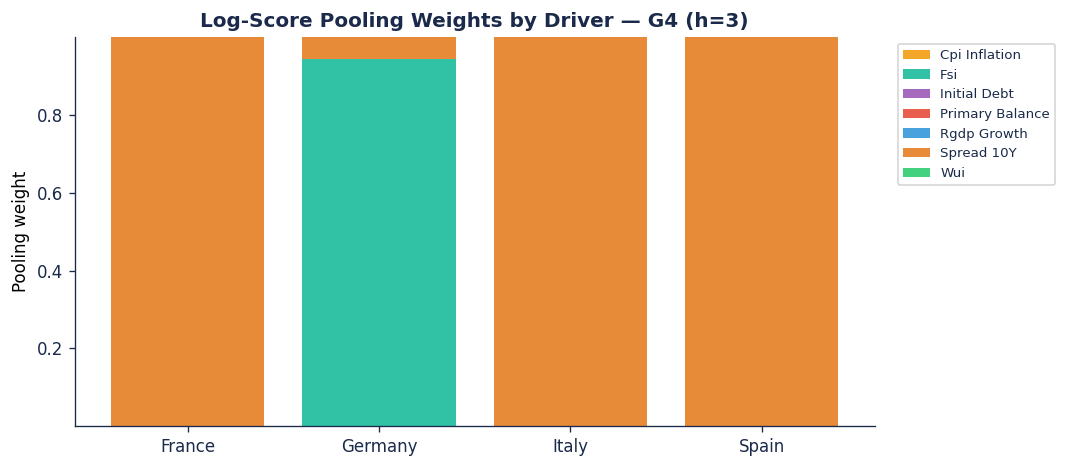

In [56]:
# Visualise pooling weights for G4 as stacked bars
g4_w = weights[weights["iso3"].isin(G4)].pivot(
    index="iso3", columns="cond_var", values="weight"
).reindex(G4)

driver_colors = {
    "primary_balance": "#E74C3C", "rgdp_growth": "#3498DB",
    "cpi_inflation": "#F39C12",   "initial_debt": "#9B59B6",
    "fsi": "#1ABC9C", "spread_10y": "#E67E22", "wui": "#2ECC71",
}

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(4)
x = np.arange(4)
labels_g4 = [{"FRA":"France","DEU":"Germany","ITA":"Italy","ESP":"Spain"}[c] for c in G4]

for cv in g4_w.columns:
    vals = g4_w[cv].fillna(0).values
    ax.bar(x, vals, bottom=bottom, color=driver_colors.get(cv, "grey"),
           label=cv.replace("_"," ").title(), alpha=0.9)
    bottom += vals

ax.set_xticks(x); ax.set_xticklabels(labels_g4)
ax.set_ylabel("Pooling weight")
ax.set_title("Log-Score Pooling Weights by Driver — G4 (h=3)", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Phase 3c — Debt-at-Risk (P5 / P50 / P95)

Extract quantiles from the pooled distribution. Re-center median to IMF WEO
April 2025 baseline projections for 2027.


In [57]:
from risk.dar import compute_dar, WEO_BASELINE_2027

print("Computing Debt-at-Risk …")
dar = compute_dar(skt_params, weights, horizon=3, recenter=True)

print("\nDebt-at-Risk results:")
print(dar[["iso3","Q05","Q50","Q95","DaR","Upside","Downside","weo_baseline"]].to_string(index=False))


Computing Debt-at-Risk …
Saved DaR results → /workspaces/debt_at_risk/risk/dar_results.parquet
  iso3     Q05    Q50     Q95     DaR  Upside  Downside  weo_baseline
0  FRA  101.93  117.0  128.08  128.08   11.08     15.07         117.0
1  DEU   46.41   68.5   84.77   84.77   16.27     22.09          68.5
2  ITA  125.55  138.0  147.15  147.15    9.15     12.45         138.0
3  ESP   88.58  103.5  114.46  114.46   10.96     14.92         103.5

Debt-at-Risk results:
iso3    Q05   Q50    Q95    DaR  Upside  Downside  weo_baseline
 FRA 101.93 117.0 128.08 128.08   11.08     15.07         117.0
 DEU  46.41  68.5  84.77  84.77   16.27     22.09          68.5
 ITA 125.55 138.0 147.15 147.15    9.15     12.45         138.0
 ESP  88.58 103.5 114.46 114.46   10.96     14.92         103.5


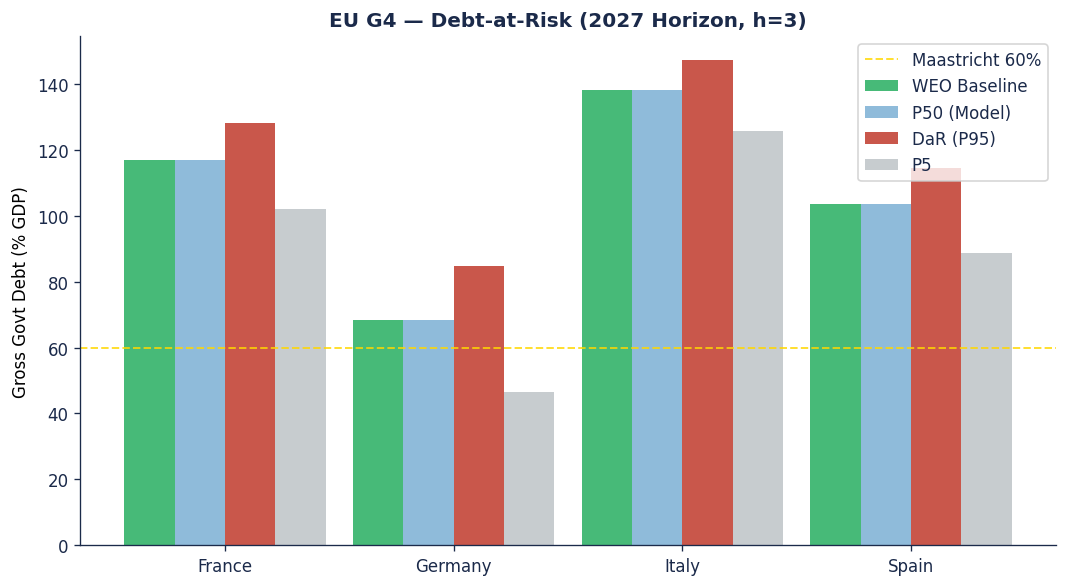

In [58]:
# DaR summary visualisation
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(G4))
labels_g4 = ["France", "Germany", "Italy", "Spain"]
width = 0.22

q05_vals = [dar[dar["iso3"]==c]["Q05"].values[0] if not dar[dar["iso3"]==c].empty else 0 for c in G4]
q50_vals = [dar[dar["iso3"]==c]["Q50"].values[0] if not dar[dar["iso3"]==c].empty else 0 for c in G4]
q95_vals = [dar[dar["iso3"]==c]["Q95"].values[0] if not dar[dar["iso3"]==c].empty else 0 for c in G4]
weo_vals = [WEO_BASELINE_2027.get(c, 0) for c in G4]

ax.bar(x - width*1.5, weo_vals, width, label="WEO Baseline", color="#27AE60", alpha=0.85)
ax.bar(x - width*0.5, q50_vals, width, label="P50 (Model)", color="#7BAFD4", alpha=0.85)
ax.bar(x + width*0.5, q95_vals, width, label="DaR (P95)",   color="#C0392B", alpha=0.85)
ax.bar(x + width*1.5, q05_vals, width, label="P5",          color="#BDC3C7", alpha=0.85)

ax.axhline(60, color="gold", lw=1.2, ls="--", alpha=0.8, label="Maastricht 60%")
ax.set_xticks(x); ax.set_xticklabels(labels_g4)
ax.set_ylabel("Gross Govt Debt (% GDP)")
ax.set_title("EU G4 — Debt-at-Risk (2027 Horizon, h=3)", fontweight="bold")
ax.legend(framealpha=0.8)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Phase 4 — Fiscal Crisis Early-Warning Logit

$$\Pr(\text{crisis}_{i,t+1,t+2}) = \Lambda\!\left(\beta_0 + \beta_1 \cdot (Q_{95} - Q_{50})_{i,t}\right)$$

Estimated separately for each conditioning variable. Binary crisis indicator from
Laeven & Valencia (2020).


In [59]:
from crisis.logit_signal import run_logit

print("Running fiscal crisis logit models …")
crisis_out = run_logit(skt_params, panel, horizon=3, forecast_years=[2025, 2026])

print("\nLogit results summary:")
for cv, res in crisis_out["logit_results"].items():
    coef_upside = res.params[1] if len(res.params) > 1 else float("nan")
    pval        = res.pvalues[1] if len(res.pvalues) > 1 else float("nan")
    print(f"  {cv:20s}  β_upside = {coef_upside:+.4f}  (p={pval:.3f})")


Running fiscal crisis logit models …
Saved crisis scores → /workspaces/debt_at_risk/crisis/crisis_scores.parquet

Logit results summary:
  primary_balance       β_upside = -0.0420  (p=0.002)
  rgdp_growth           β_upside = -0.0589  (p=0.000)
  cpi_inflation         β_upside = -0.0555  (p=0.001)
  initial_debt          β_upside = -0.0522  (p=0.000)
  fsi                   β_upside = +0.3587  (p=0.000)
  spread_10y            β_upside = +1.4085  (p=0.047)
  wui                   β_upside = -0.0584  (p=0.000)



G4 Fiscal Crisis Probability Scores:
iso3  year  crisis_prob_pooled
 DEU  2025            0.054936
 DEU  2026            0.054936
 ESP  2025            0.024024
 ESP  2026            0.024024
 FRA  2025            0.044773
 FRA  2026            0.044773
 ITA  2025            0.014866
 ITA  2026            0.014866


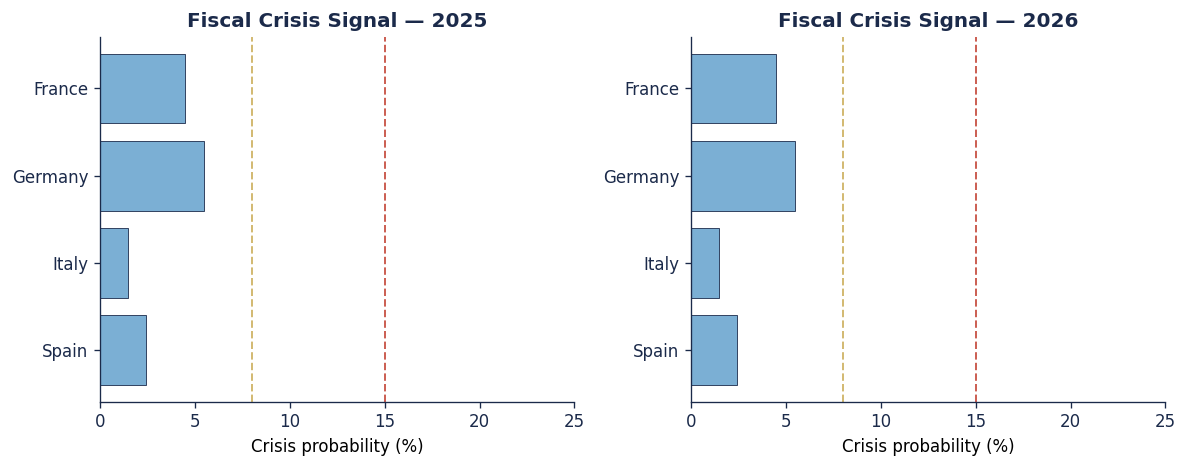

In [60]:
# G4 crisis probability scores
pooled = crisis_out["pooled_scores"]
print("\nG4 Fiscal Crisis Probability Scores:")
print(pooled[pooled["iso3"].isin(G4)].to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, yr in zip(axes, [2025, 2026]):
    sub = pooled[(pooled["iso3"].isin(G4)) & (pooled["year"] == yr)].copy()
    if sub.empty:
        ax.set_title(str(yr))
        continue
    sub = sub.set_index("iso3").reindex(G4)
    probs = sub["crisis_prob_pooled"].fillna(0).values * 100
    labels_g4 = ["France", "Germany", "Italy", "Spain"]
    bar_colors = ["#C0392B" if p > 15 else "#C8A951" if p > 8 else "#7BAFD4"
                  for p in probs]
    ax.barh(labels_g4, probs, color=bar_colors, edgecolor="#1B2A4A", linewidth=0.5)
    ax.axvline(8,  color="#C8A951", lw=1.2, ls="--", alpha=0.8)
    ax.axvline(15, color="#C0392B", lw=1.2, ls="--", alpha=0.8)
    ax.set_xlabel("Crisis probability (%)")
    ax.set_title(f"Fiscal Crisis Signal — {yr}", fontweight="bold")
    ax.set_xlim(0, max(probs.max() + 5, 25))
    ax.spines[["top","right"]].set_visible(False)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Phase 5 — Generate All Charts

In [61]:
from output.charts import generate_all_charts

chart_paths = generate_all_charts(panel, dar, skt_params, pooled)
for name, path in chart_paths.items():
    print(f"  {name}: {path}")


Generating charts …


  Saved → /workspaces/debt_at_risk/output/fig0_global_context.png
  Saved → /workspaces/debt_at_risk/output/fig1_fan_charts.png
  Saved → /workspaces/debt_at_risk/output/fig2_comparison_bar.png
  Saved → /workspaces/debt_at_risk/output/fig3_waterfall.png
  Saved → /workspaces/debt_at_risk/output/fig4_crisis_signal.png
  global_context: /workspaces/debt_at_risk/output/fig0_global_context.png
  fan_charts: /workspaces/debt_at_risk/output/fig1_fan_charts.png
  comparison_bar: /workspaces/debt_at_risk/output/fig2_comparison_bar.png
  waterfall: /workspaces/debt_at_risk/output/fig3_waterfall.png
  crisis_signal: /workspaces/debt_at_risk/output/fig4_crisis_signal.png


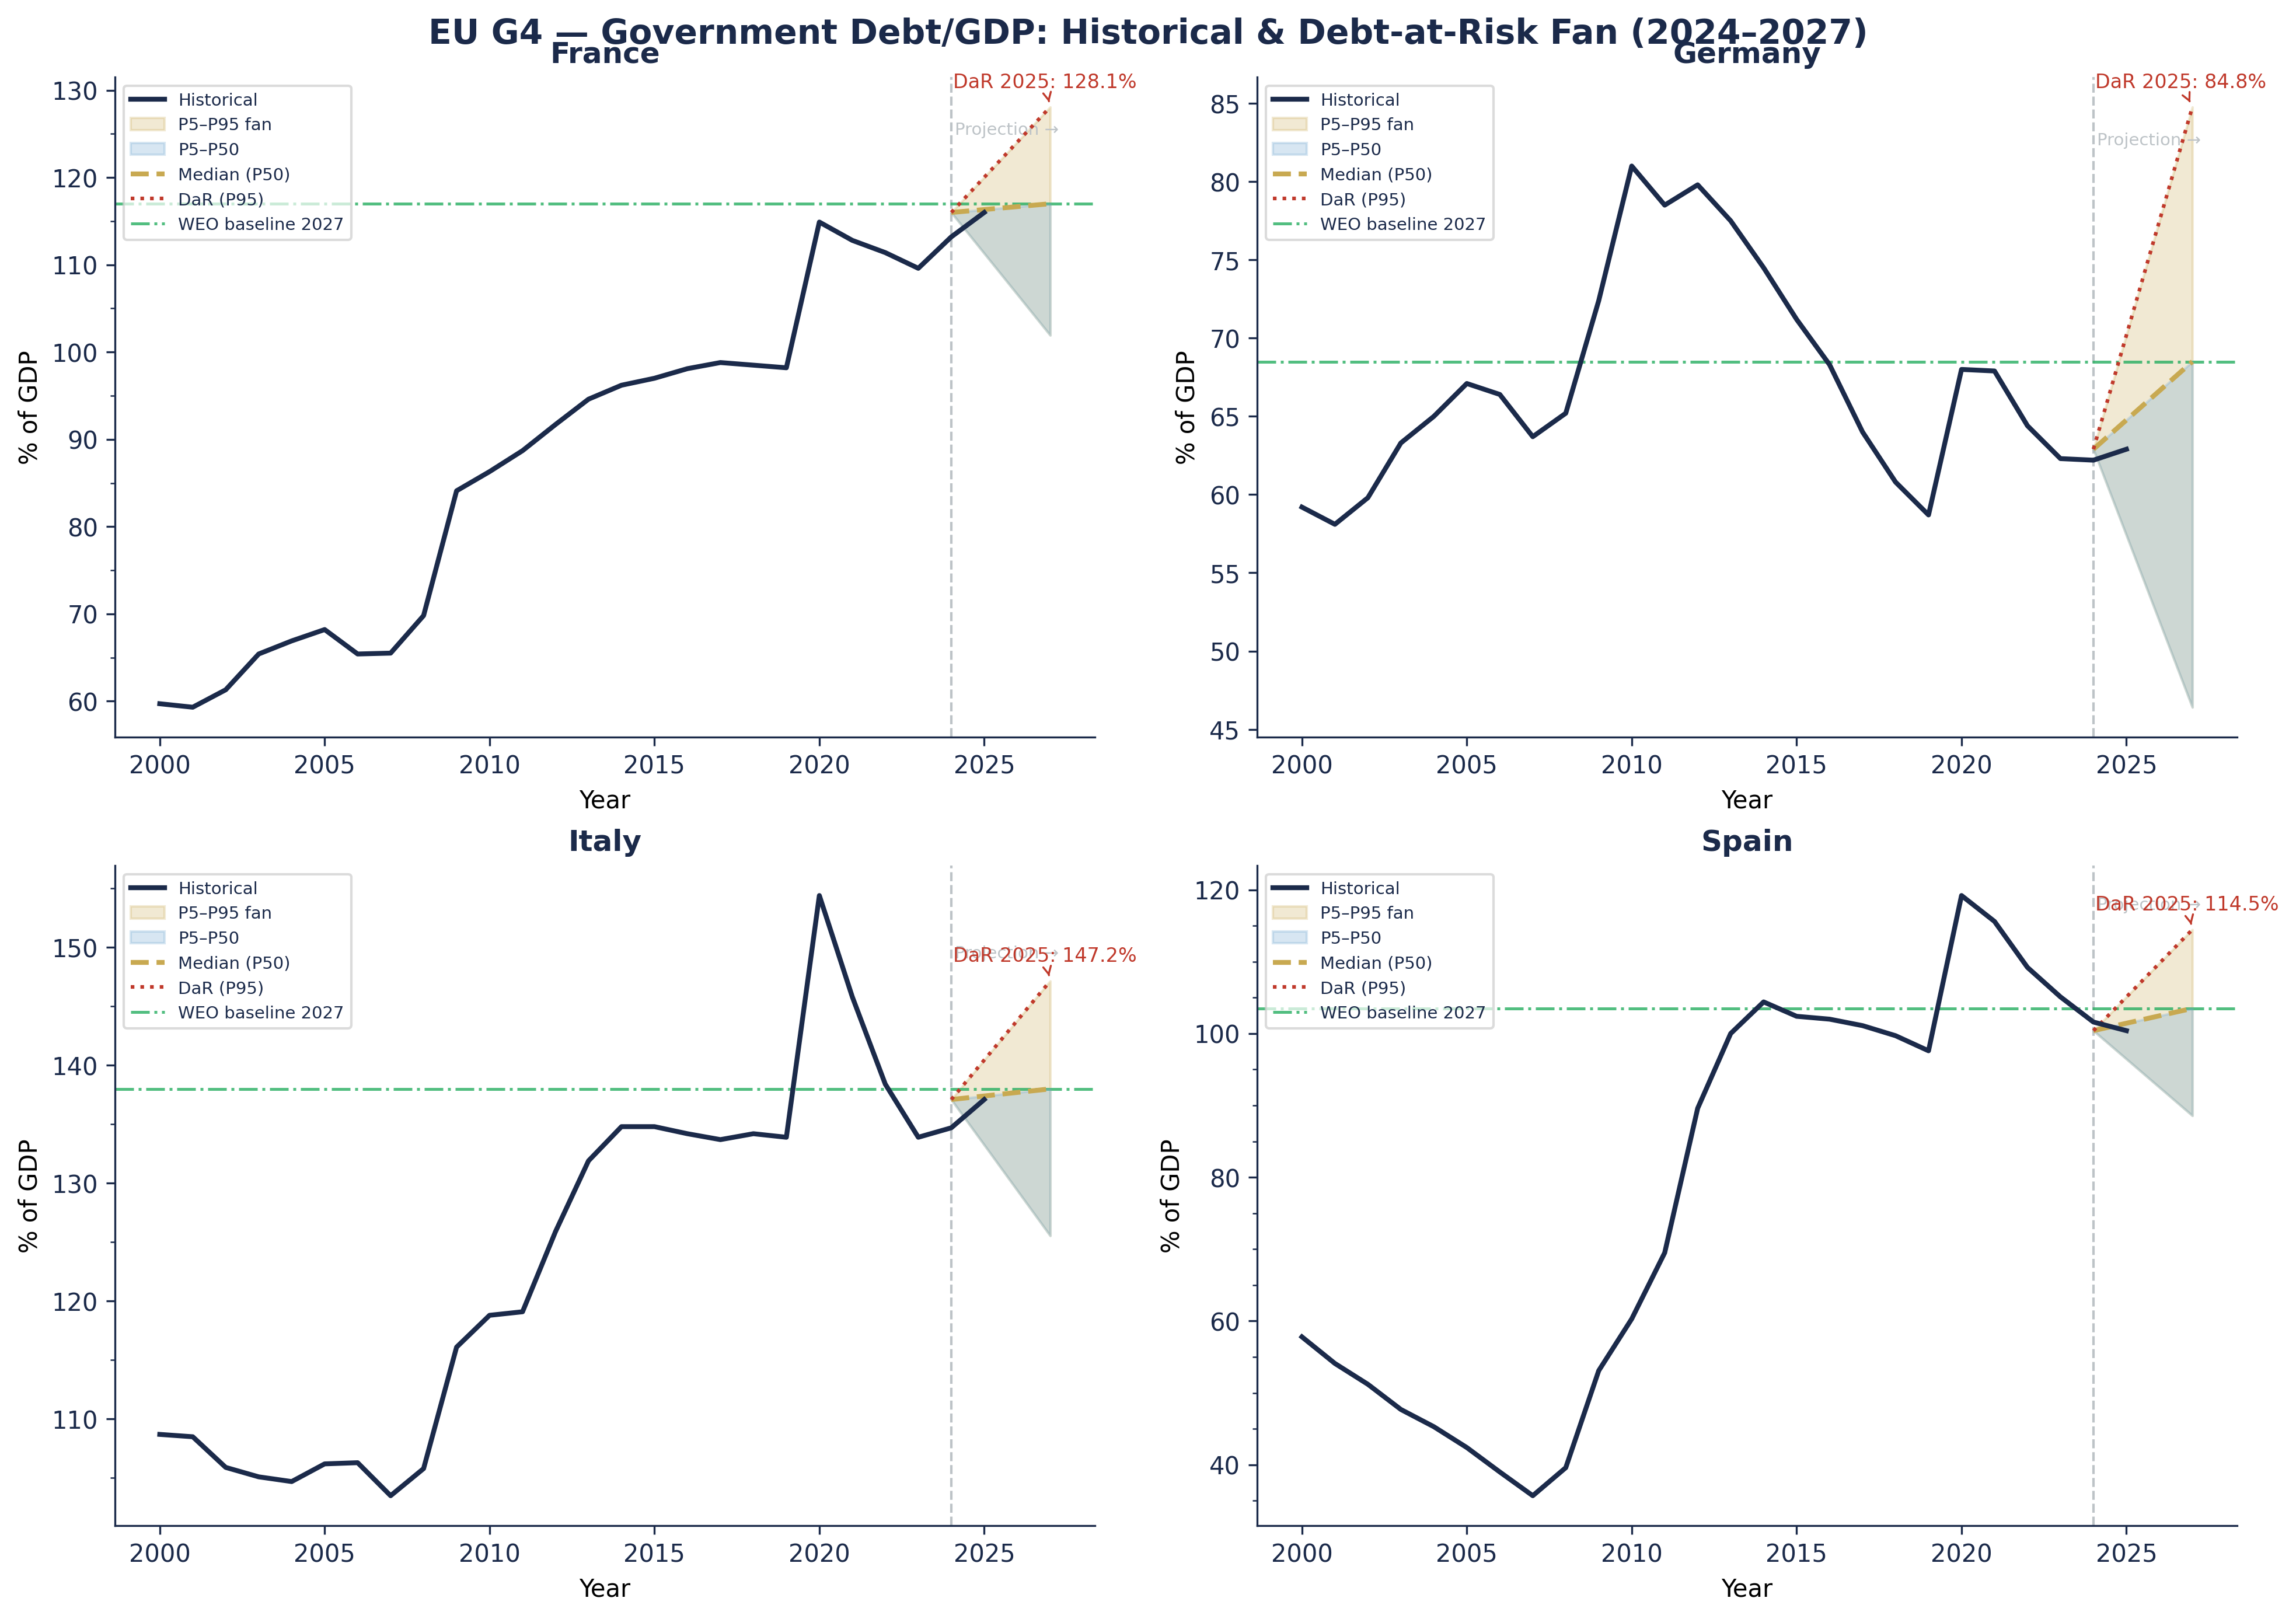

In [62]:
# Display fan charts inline
from IPython.display import Image, display
fan_path = chart_paths.get("fan_charts")
if fan_path and fan_path.exists():
    display(Image(filename=str(fan_path), width=950))


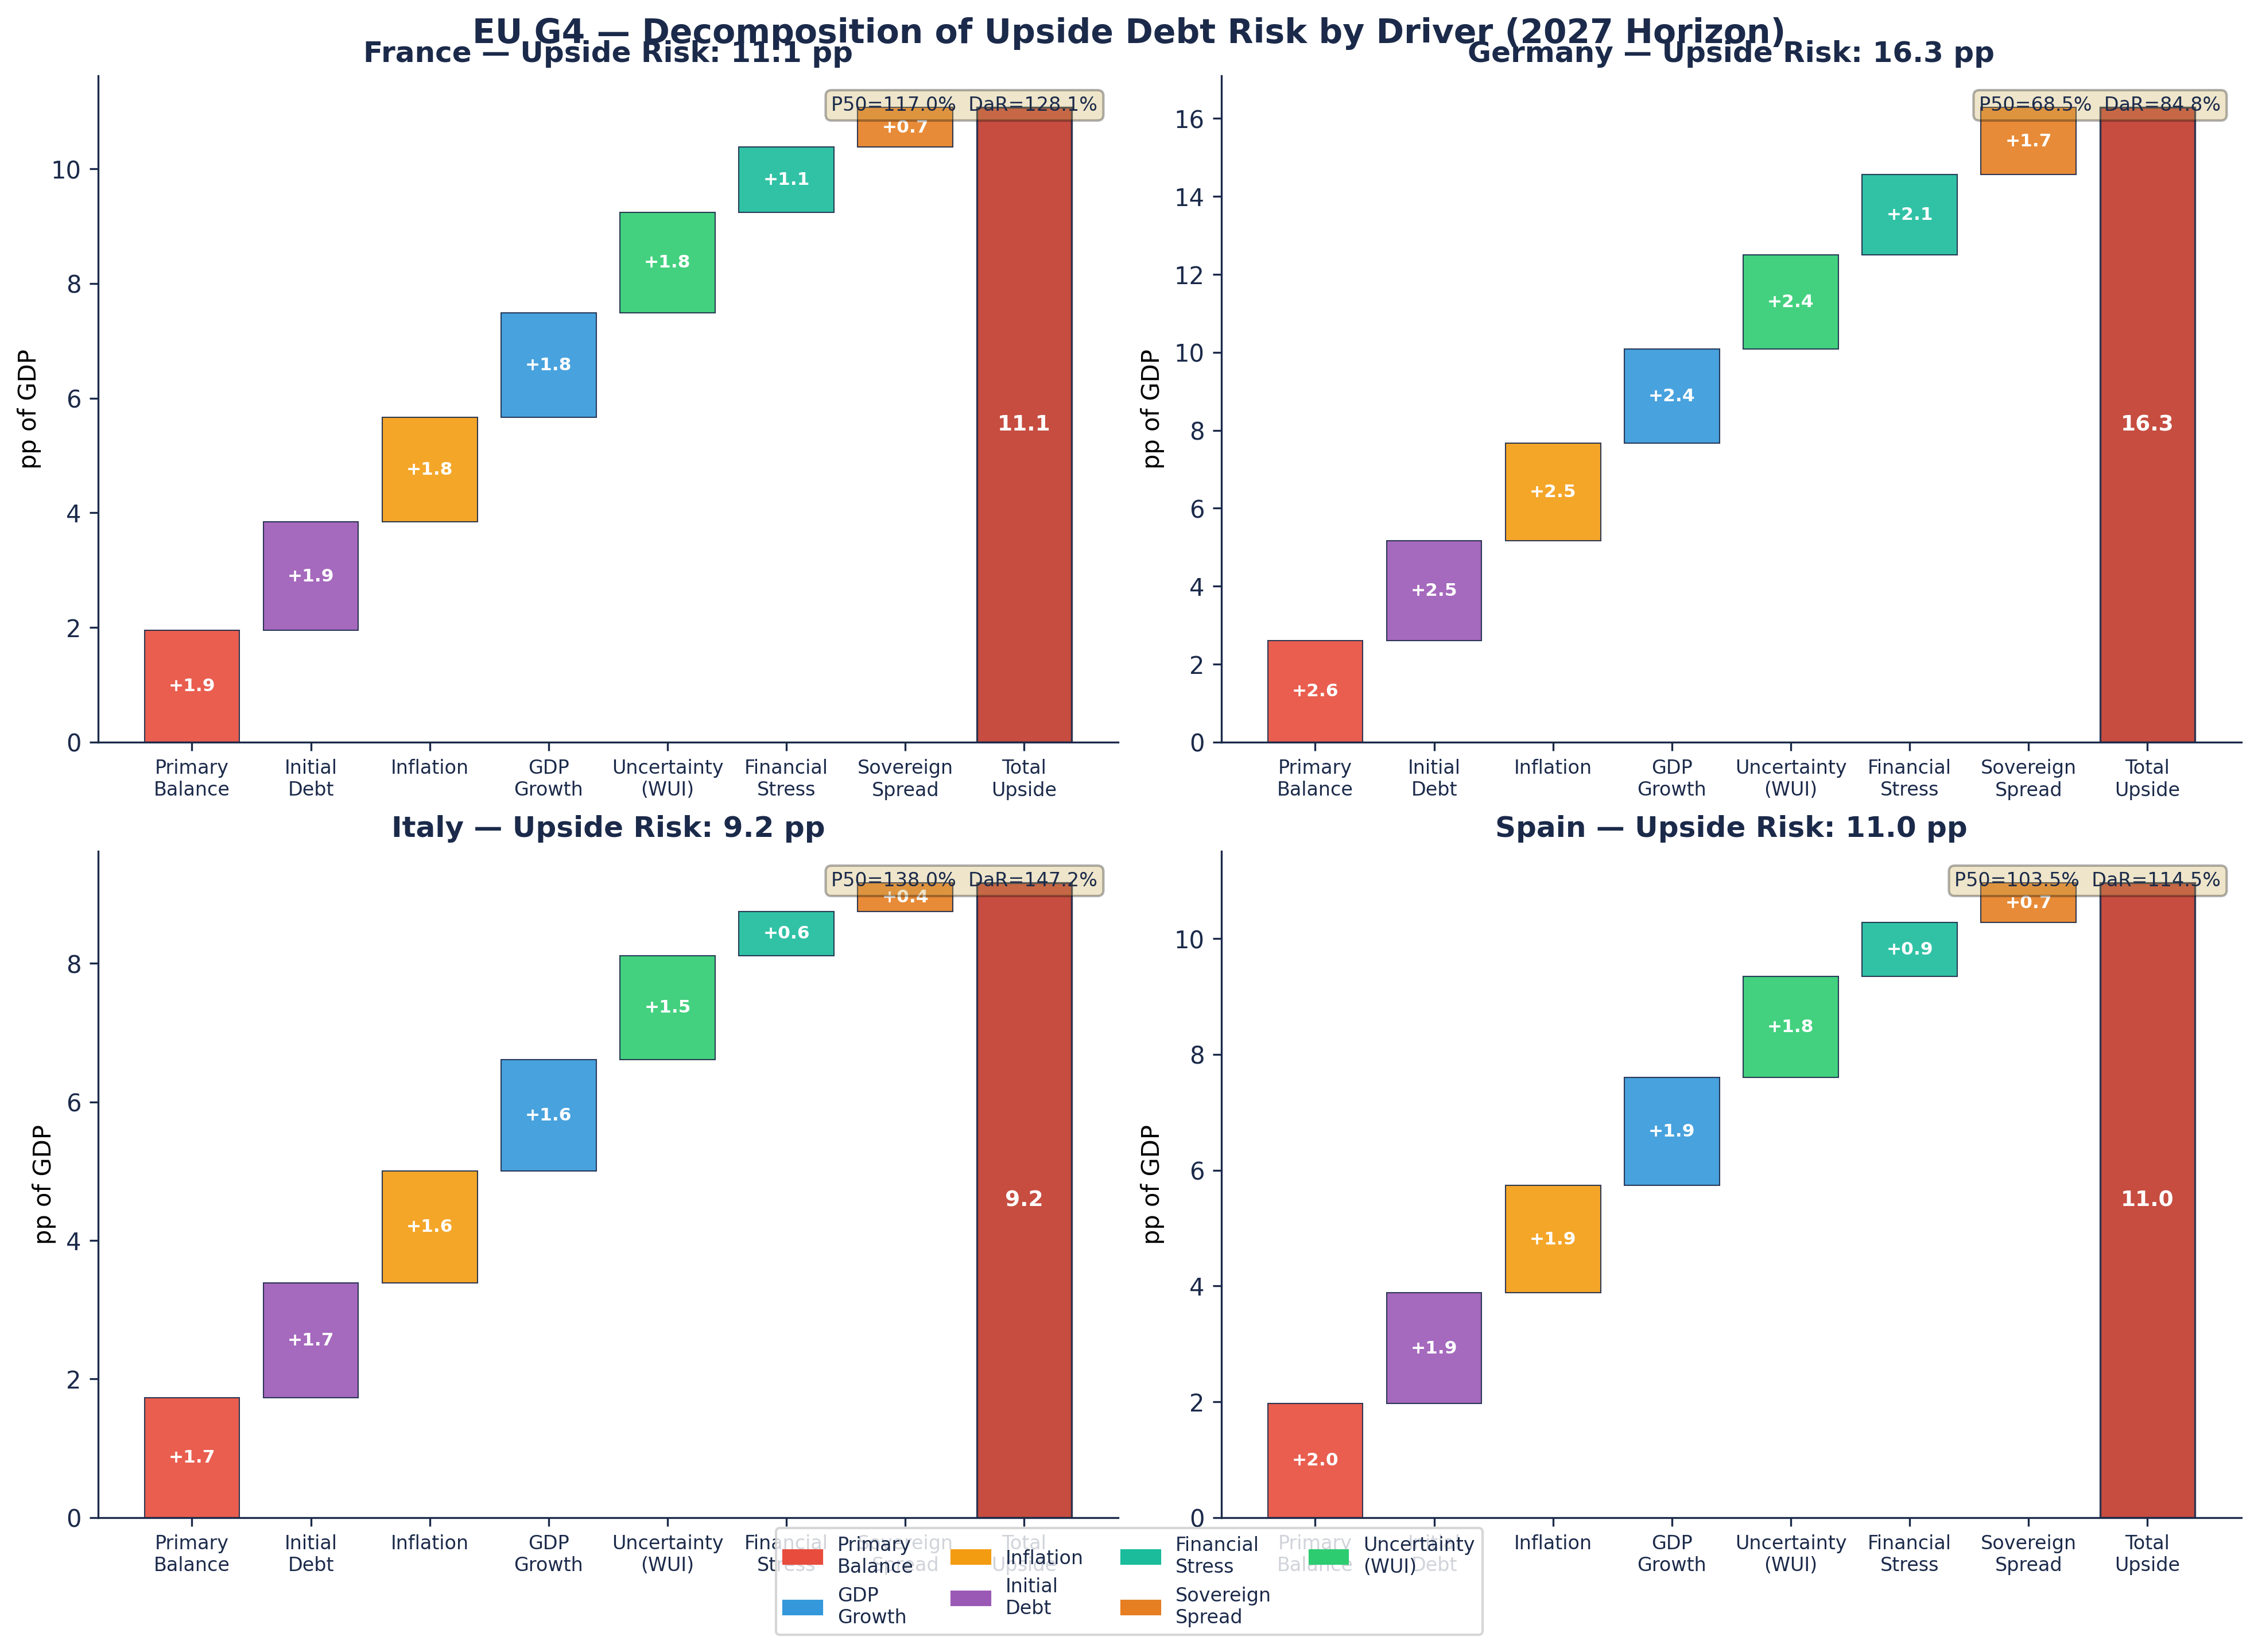

In [63]:
# Display waterfall
wf_path = chart_paths.get("waterfall")
if wf_path and wf_path.exists():
    display(Image(filename=str(wf_path), width=950))


## Build PowerPoint Deck

In [64]:
from output.deck import build_deck

deck_path = build_deck(dar, pooled, chart_paths)
print(f"\nDeck saved to: {deck_path}")


  Building slides …
  Saved deck → /workspaces/debt_at_risk/output/eu_g4_debt_at_risk.pptx

Deck saved to: /workspaces/debt_at_risk/output/eu_g4_debt_at_risk.pptx


## Summary — EU G4 Debt-at-Risk Results

| Country | WEO Baseline | Median (P50) | DaR (P95) | Upside | Downside |
|---------|-------------|-------------|-----------|--------|----------|


In [65]:
summary = dar[["iso3","weo_baseline","Q50","DaR","Upside","Downside"]].copy()
summary.columns = ["Country","WEO Baseline","Median (P50)","DaR (P95)","Upside (+pp)","Downside (−pp)"]
summary["Country"] = summary["Country"].map(
    {"FRA":"France","DEU":"Germany","ITA":"Italy","ESP":"Spain"}
)
print(summary.to_string(index=False))


Country  WEO Baseline  Median (P50)  DaR (P95)  Upside (+pp)  Downside (−pp)
 France         117.0         117.0     128.08         11.08           15.07
Germany          68.5          68.5      84.77         16.27           22.09
  Italy         138.0         138.0     147.15          9.15           12.45
  Spain         103.5         103.5     114.46         10.96           14.92
